In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import os
import time
import copy
import torch.nn.functional as F


In [ ]:
import torch
import numpy as np
import random

seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Copy dataset from google drive.
!cp "/content/drive/MyDrive/new_dataset.zip" "/content/new_dataset.zip"

# Unzip it
!unzip -q /content/new_dataset.zip -d /content/

Define Transforms and Load Custom Data Structure

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import cv2
from PIL import Image
import random

# Set your root directory (dataset)
root_dir = '/content/new_dataset'
train_dir = f'{root_dir}/Training'
test_dir = f'{root_dir}/Testing'

BATCH_SIZE = 32


# ======================================================
# Custom Contrast Enhancement 
# ======================================================
def contrast_enhancement(img):
    f_min = np.min(img)
    f_max = np.max(img)
    bpp = 8

    g = ((img - f_min) / (f_max - f_min + 1e-8)) * (2 ** bpp - 1)
    g = np.clip(g, 0, 255).astype(np.uint8)
    return g


# ======================================================
# Custom Augmentation Wrapper
# Applies ONE random augmentation per call
# ======================================================
class CustomAugmentation:
    def __call__(self, img):
        # Convert PIL -> numpy grayscale
        img = np.array(img.convert("L"))

        # Contrast enhancement first
        img = contrast_enhancement(img)

        # Choose random augmentation
        choice = random.choice([
            "rot90", "rot180", "rot270",
            "flip_v", "flip_h", "none"
        ])

        if choice == "rot90":
            img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

        elif choice == "rot180":
            img = cv2.rotate(img, cv2.ROTATE_180)

        elif choice == "rot270":
            img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        elif choice == "flip_v":
            img = cv2.flip(img, 0)

        elif choice == "flip_h":
            img = cv2.flip(img, 1)

        # Convert back numpy -> PIL
        return Image.fromarray(img)


# ======================================================
# Define Transforms
# ======================================================

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),

    # ✅ YOUR AUGMENTATION HERE
    CustomAugmentation(),

    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),

    # Only contrast enhancement (no rotation/flip)
    transforms.Lambda(
        lambda img: Image.fromarray(
            contrast_enhancement(np.array(img.convert("L")))
        )
    ),

    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


# ======================================================
# Load Datasets
# ======================================================
try:
    test_data = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

    full_train_aug = datasets.ImageFolder(root=train_dir, transform=train_transforms)
    full_train_clean = datasets.ImageFolder(root=train_dir, transform=val_test_transforms)

    total_train_imgs = len(full_train_aug)
    val_size = int(0.2 * total_train_imgs)
    train_size = total_train_imgs - val_size

    torch.manual_seed(42)
    indices = torch.randperm(total_train_imgs).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_data = Subset(full_train_aug, train_indices)
    val_data = Subset(full_train_clean, val_indices)

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Classes found: {test_data.classes}")
    print("Data Distribution:")
    print(f"  - Training Set:   {len(train_data)} images (Custom Augmentation)")
    print(f"  - Validation Set: {len(val_data)} images")
    print(f"  - Test Set:       {len(test_data)} images")

    # Sanity check
    x, y = next(iter(train_loader))
    print("Sample batch shape:", x.shape)  # Should be [32,1,224,224]

except FileNotFoundError:
    print(f"Error: Could not find directories at {root_dir}.")

Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Data Distribution:
  - Training Set:   4570 images (Custom Augmentation)
  - Validation Set: 1142 images
  - Test Set:       1311 images
Sample batch shape: torch.Size([32, 1, 224, 224])


Transformer Encoder Block

In [ ]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)

        mlp_out = self.mlp(x)
        x = self.norm2(x + mlp_out)

        return x

Vision Transformer Encoder Block

In [ ]:
class ViTEncoder(nn.Module):
    def __init__(self, depth, embed_dim, num_heads, mlp_dim):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim)
            for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

ResNet34 + Vision Transformer Hybrid Architecture with Custom Classification Head

In [ ]:
class ResNet34ViT(nn.Module):
    def __init__(self, num_classes,dropout1 = 0.5,dropout2 = 0.5):
        super().__init__()

        # -------- ResNet34 Backbone --------
        resnet = models.resnet34(pretrained=True)

        # Modify first conv layer for 1-channel MRI
        resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Remove avgpool and fc
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # -------- Token Projection --------
        self.token_proj = nn.Linear(512, 256)

        # -------- CLS Token --------
        self.cls_token = nn.Parameter(torch.randn(1, 1, 256))

        # 49 patches + 1 CLS = 50 tokens
        self.pos_embedding = nn.Parameter(torch.randn(1, 50, 256))

        # -------- ViT Encoder --------
        self.vit = ViTEncoder(
            depth=4,
            embed_dim=256,
            num_heads=4,
            mlp_dim=512
        )

        # -------- Classification Head --------
        #self.classifier = nn.Linear(256, num_classes)

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(256),
            nn.Dropout(dropout1),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout2),
            nn.Linear(256, num_classes)
        )


    def forward(self, x):
        B = x.size(0)

        # CNN feature extraction
        x = self.backbone(x)               # [B, 512, 7, 7]
        x = x.flatten(2).transpose(1, 2)   # [B, 49, 512]

        # Project tokens
        x = self.token_proj(x)             # [B, 49, 256]

        # Add CLS token
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)  # [B, 50, 256]

        # Add positional embedding
        x = x + self.pos_embedding

        # Transformer encoder
        x = self.vit(x)

        # Classification using CLS token
        out = self.classifier(x[:, 0])

        return out

In [ ]:
num_classes = 4  # tumor classes
batch_size = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet34ViT(num_classes).to(device)

Training and Testing Epoch

In [ ]:
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # ✅ Gradient Clipping (VERY IMPORTANT for stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    return train_loss, train_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.0005):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.stop = False

    def step(self, current_score):
        # current_score = val_acc (higher is better)
        if self.best_score is None:
            self.best_score = current_score
            return

        if current_score > self.best_score + self.min_delta:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


In [ ]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []


Training Loop

In [ ]:
import torch
from torch.optim.optimizer import Optimizer

epochs = 50

# ✅ Loss
criterion = nn.CrossEntropyLoss()

# ✅ Ranger Optimizer (Recommended LR for Hybrid)
#optimizer = Ranger(model.parameters(), lr=5e-5, weight_decay=1e-4)

#Adam Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)



# ✅ Scheduler (reduces LR automatically when Val Acc stops improving)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=3,
    min_lr=1e-8
)

# ✅ Early stopping
early_stopping = EarlyStopping(patience=7, min_delta=0.0005)

best_val_acc = 0.0
best_epoch = 0

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device, grad_clip=1.0
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_acc)

    # ✅ Store values
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    # ✅ Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_resnet34_vit_ranger.pth")
        print(f"✅ Best model saved at epoch {best_epoch} with Val Acc: {best_val_acc:.4f}")

    # ✅ Early stopping check
    early_stopping.step(val_acc)
    if early_stopping.stop:
        print(f"🛑 Early stopping triggered at epoch {epoch+1}. Best epoch: {best_epoch}")
        break


Epoch [1/50] | Train Loss: 0.5405, Train Acc: 0.7976 | Val Loss: 0.2606, Val Acc: 0.8932
✅ Best model saved at epoch 1 with Val Acc: 0.8932
Epoch [2/50] | Train Loss: 0.2795, Train Acc: 0.9109 | Val Loss: 0.2004, Val Acc: 0.9378
✅ Best model saved at epoch 2 with Val Acc: 0.9378
Epoch [3/50] | Train Loss: 0.2298, Train Acc: 0.9221 | Val Loss: 0.1010, Val Acc: 0.9658
✅ Best model saved at epoch 3 with Val Acc: 0.9658
Epoch [4/50] | Train Loss: 0.2117, Train Acc: 0.9341 | Val Loss: 0.1814, Val Acc: 0.9431
Epoch [5/50] | Train Loss: 0.1940, Train Acc: 0.9429 | Val Loss: 0.1578, Val Acc: 0.9501
Epoch [6/50] | Train Loss: 0.1640, Train Acc: 0.9512 | Val Loss: 0.1333, Val Acc: 0.9527
Epoch [7/50] | Train Loss: 0.1527, Train Acc: 0.9501 | Val Loss: 0.2355, Val Acc: 0.9343
Epoch [8/50] | Train Loss: 0.0974, Train Acc: 0.9722 | Val Loss: 0.0593, Val Acc: 0.9816
✅ Best model saved at epoch 8 with Val Acc: 0.9816
Epoch [9/50] | Train Loss: 0.0799, Train Acc: 0.9768 | Val Loss: 0.0879, Val Acc: 0.

Training and Validation - Accuracy and Loss Curve

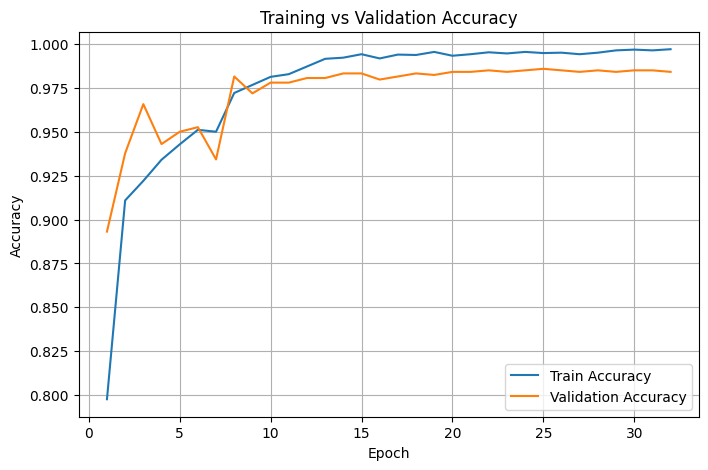

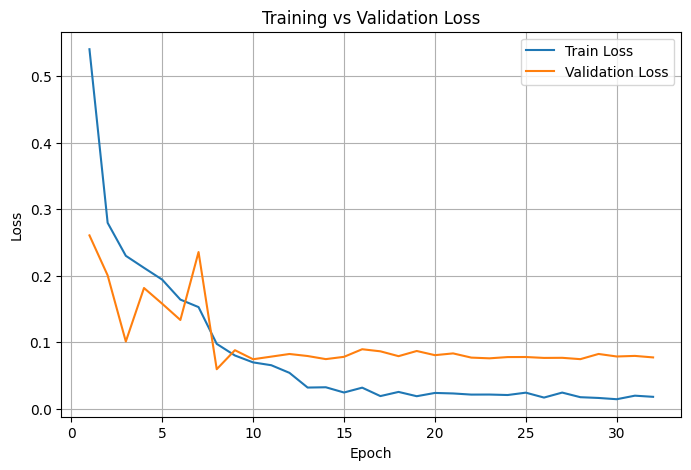

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

# ================= Accuracy Graph =================
plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, val_accs, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ================= Loss Graph =================
plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Load the Best Model

In [ ]:
import torch

model.load_state_dict(torch.load("best_resnet34_vit_ranger.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Best model loaded for test evaluation!")

✅ Best model loaded for test evaluation!


Testing the Best Model

In [ ]:
import numpy as np
import torch

def evaluate_test(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / total
    test_acc = correct / total

    return test_loss, test_acc, np.array(all_labels), np.array(all_preds)

In [ ]:
test_loss, test_acc, y_true, y_pred = evaluate_test(model, test_loader, criterion, device)

print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")

✅ Test Loss: 0.0277
✅ Test Accuracy: 0.9947


Confustion Matrix and Classification Report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

class_names = ["glioma", "meningioma", "pituitary", "notumor"]

cm = confusion_matrix(y_true, y_pred)

print("✅ Confusion Matrix:\n", cm)

print("\n✅ Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))



✅ Confusion Matrix:
 [[296   4   0   0]
 [  0 304   1   1]
 [  0   0 405   0]
 [  0   1   0 299]]

✅ Classification Report:

              precision    recall  f1-score   support

      glioma     1.0000    0.9867    0.9933       300
  meningioma     0.9838    0.9935    0.9886       306
   pituitary     0.9975    1.0000    0.9988       405
     notumor     0.9967    0.9967    0.9967       300

    accuracy                         0.9947      1311
   macro avg     0.9945    0.9942    0.9943      1311
weighted avg     0.9947    0.9947    0.9947      1311



Confusion Matrix Plot

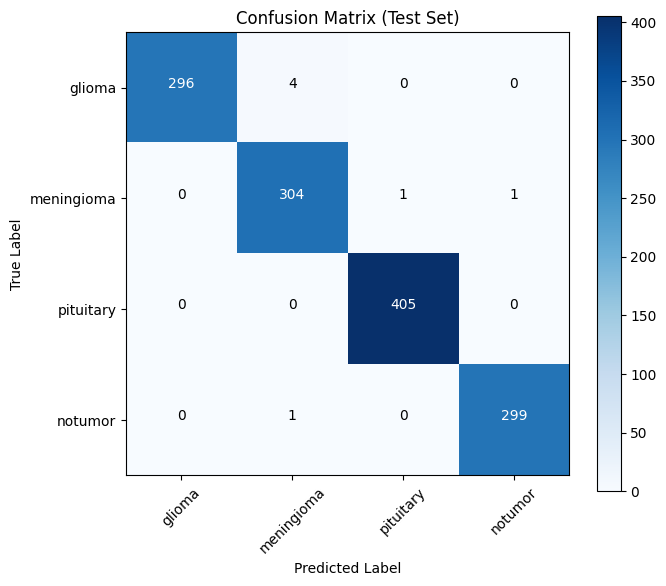

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(7, 6))

    # ✅ White + Blue color map
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)

    plt.title("Confusion Matrix (Test Set)")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Write numbers inside cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, cm[i, j],
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_names)


FROC Curve, MCC, Cohen Kappa, ECE

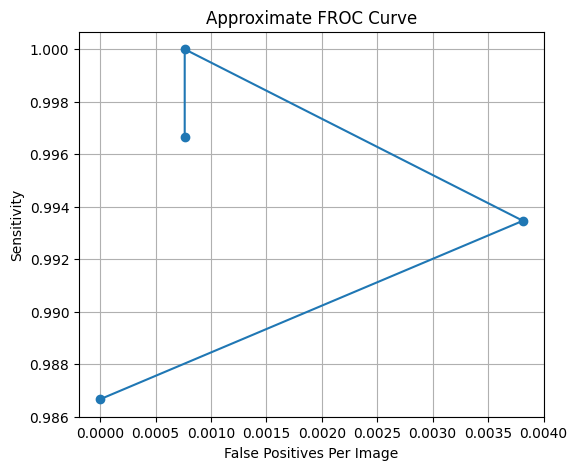

=========== METRICS ===========
MCC: 0.9928
Cohen Kappa: 0.9928
ECE: 0.0044


In [ ]:
# ================================
# ALL METRICS CELL
# ================================
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix

# ----------------------------
# Inference
# ----------------------------
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

# ----------------------------
# 1️⃣ Matthews Correlation
# ----------------------------
mcc = matthews_corrcoef(y_true, y_pred)

# ----------------------------
# 2️⃣ Cohen Kappa
# ----------------------------
kappa = cohen_kappa_score(y_true, y_pred)

# ----------------------------
# 3️⃣ Expected Calibration Error
# ----------------------------
def compute_ece(probs, labels, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    bins = np.linspace(0,1,n_bins+1)
    ece = 0

    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if np.any(mask):
            acc = np.mean(predictions[mask] == labels[mask])
            conf = np.mean(confidences[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(labels)

    return ece

ece = compute_ece(y_probs, y_true)

# ----------------------------
# 4️⃣ FROC-style curve (classification approximation)
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp

num_images = len(y_true)

sensitivity = tp / (tp + (cm.sum(axis=1) - tp) + 1e-8)
fppi = fp / num_images

plt.figure(figsize=(6,5))
plt.plot(fppi, sensitivity, marker='o')
plt.xlabel("False Positives Per Image")
plt.ylabel("Sensitivity")
plt.title("Approximate FROC Curve")
plt.grid()
plt.show()

# ----------------------------
# Print Results
# ----------------------------
print("=========== METRICS ===========")
print(f"MCC: {mcc:.4f}")
print(f"Cohen Kappa: {kappa:.4f}")
print(f"ECE: {ece:.4f}")
print("================================")
